<a href="https://colab.research.google.com/github/mahalakshmikr08/FraudShield-AI-/blob/main/FraudShield_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# 💳 FRAUDSHIELD AI
# Intelligent Credit Card Fraud Detection & Risk Scoring
# ============================================================

print("=" * 70)
print("💳 FRAUDSHIELD AI")
print("Intelligent Credit Card Fraud Detection & Risk Scoring System")
print("=" * 70)
print("🚀 Project initialized successfully!")

💳 FRAUDSHIELD AI
Intelligent Credit Card Fraud Detection & Risk Scoring System
🚀 Project initialized successfully!


In [2]:
# ============================================================
# INSTALL REQUIRED LIBRARIES
# ============================================================

!pip -q install kagglehub xgboost shap gradio imbalanced-learn joblib

In [3]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import os
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_curve
)

import shap
import joblib

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [4]:
# ============================================================
# DOWNLOAD CREDIT CARD FRAUD DATASET
# ============================================================

import kagglehub

print("⬇️ Downloading dataset...")

dataset_path = kagglehub.dataset_download(
    "mlg-ulb/creditcardfraud"
)

print("\n✅ Dataset downloaded!")
print("Dataset location:")
print(dataset_path)

⬇️ Downloading dataset...
Using Colab cache for faster access to the 'creditcardfraud' dataset.

✅ Dataset downloaded!
Dataset location:
/kaggle/input/creditcardfraud


In [5]:
# ============================================================
# LOCATE CSV FILE
# ============================================================

csv_files = glob.glob(
    os.path.join(dataset_path, "**", "*.csv"),
    recursive=True
)

print("CSV files found:")

for file in csv_files:
    print(file)

CSV files found:
/kaggle/input/creditcardfraud/creditcard.csv


In [6]:
# ============================================================
# LOAD DATASET
# ============================================================

csv_path = csv_files[0]

df = pd.read_csv(csv_path)

print("✅ Dataset loaded successfully!")
print()
print("Dataset shape:", df.shape)

✅ Dataset loaded successfully!

Dataset shape: (284807, 31)


In [7]:
# ============================================================
# FIRST LOOK
# ============================================================

print("First 5 transactions:")
display(df.head())

First 5 transactions:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [8]:
# ============================================================
# DATASET INFORMATION
# ============================================================

print("Dataset Information")
print("=" * 60)

df.info()

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  flo

In [9]:
# ============================================================
# CHECK MISSING VALUES
# ============================================================

missing_values = df.isnull().sum()

print("Missing values per column:")
display(missing_values[missing_values > 0])

print("\nTotal missing values:", missing_values.sum())

Missing values per column:


,0



Total missing values: 0


In [10]:
# ============================================================
# CHECK DUPLICATES
# ============================================================

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 1081


In [11]:
# ============================================================
# FRAUD DISTRIBUTION
# ============================================================

class_counts = df["Class"].value_counts()

print("Transaction classes:")
print(class_counts)

print("\nClass percentages:")
print(
    df["Class"]
    .value_counts(normalize=True)
    .mul(100)
    .round(4)
)

Transaction classes:
Class
0    284315
1       492
Name: count, dtype: int64

Class percentages:
Class
0    99.8273
1     0.1727
Name: proportion, dtype: float64


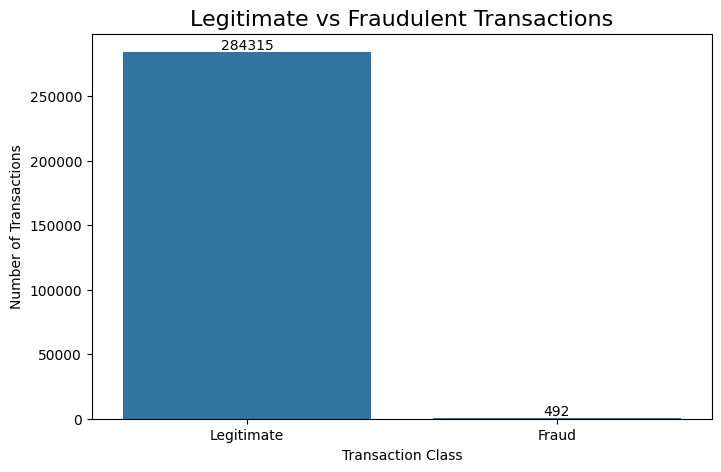

In [12]:
# ============================================================
# LEGITIMATE VS FRAUD
# ============================================================

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="Class"
)

plt.title(
    "Legitimate vs Fraudulent Transactions",
    fontsize=16
)

plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

plt.xticks(
    [0, 1],
    ["Legitimate", "Fraud"]
)

for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [13]:
# ============================================================
# FRAUD RATE
# ============================================================

total_transactions = len(df)
fraud_transactions = int(df["Class"].sum())

fraud_rate = (
    fraud_transactions /
    total_transactions
) * 100

print(f"Total transactions : {total_transactions:,}")
print(f"Fraud transactions : {fraud_transactions:,}")
print(f"Fraud rate         : {fraud_rate:.4f}%")

Total transactions : 284,807
Fraud transactions : 492
Fraud rate         : 0.1727%


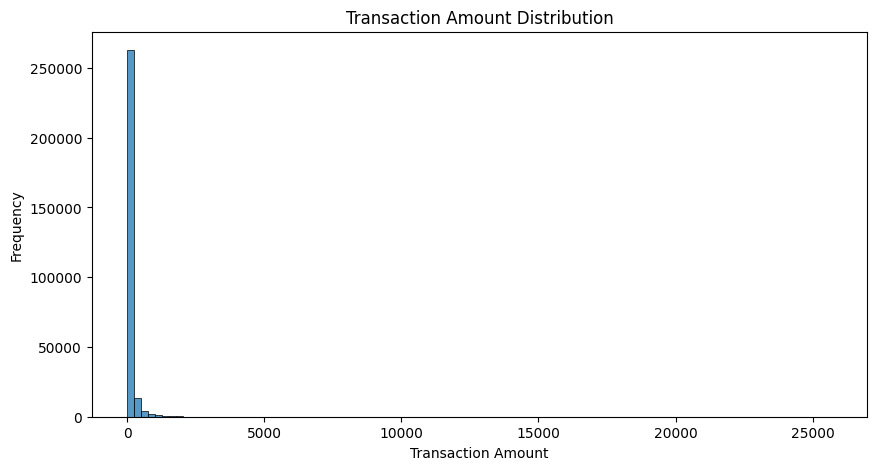

In [14]:
# ============================================================
# TRANSACTION AMOUNT ANALYSIS
# ============================================================

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Amount",
    bins=100
)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

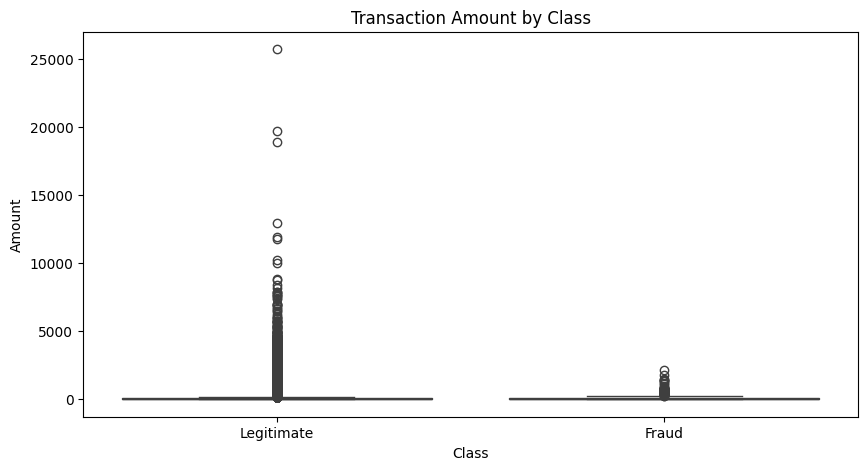

In [15]:
# ============================================================
# AMOUNT: LEGITIMATE VS FRAUD
# ============================================================

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount"
)

plt.title("Transaction Amount by Class")

plt.xticks(
    [0, 1],
    ["Legitimate", "Fraud"]
)

plt.show()

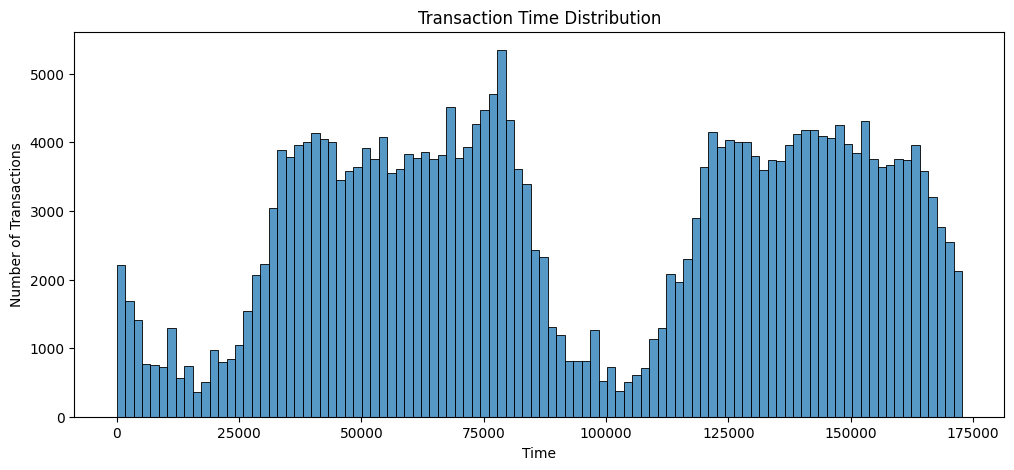

In [16]:
# ============================================================
# TRANSACTION TIME DISTRIBUTION
# ============================================================

plt.figure(figsize=(12, 5))

sns.histplot(
    data=df,
    x="Time",
    bins=100
)

plt.title("Transaction Time Distribution")
plt.xlabel("Time")
plt.ylabel("Number of Transactions")

plt.show()

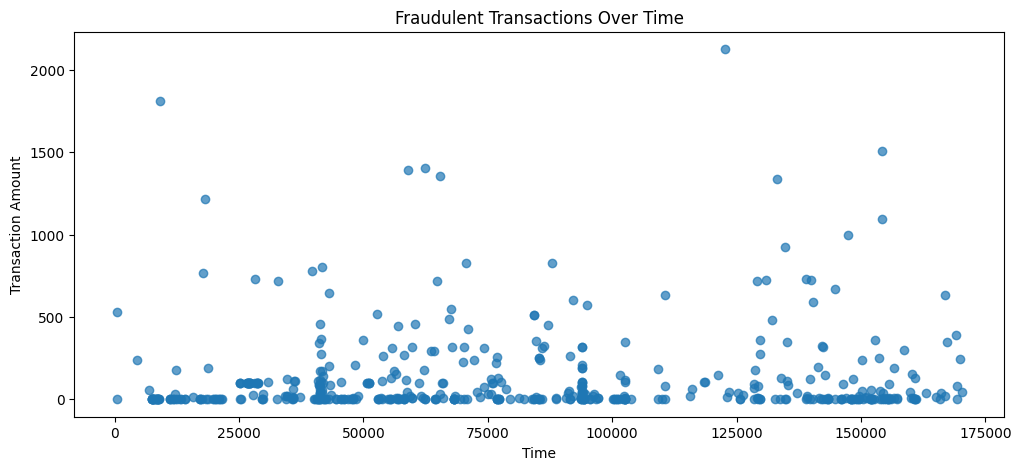

In [17]:
# ============================================================
# FRAUD TRANSACTIONS OVER TIME
# ============================================================

fraud_df = df[df["Class"] == 1]

plt.figure(figsize=(12, 5))

plt.scatter(
    fraud_df["Time"],
    fraud_df["Amount"],
    alpha=0.7
)

plt.title("Fraudulent Transactions Over Time")
plt.xlabel("Time")
plt.ylabel("Transaction Amount")

plt.show()

In [18]:
# ============================================================
# FEATURE CORRELATION WITH FRAUD
# ============================================================

correlations = (
    df.corr(numeric_only=True)["Class"]
    .sort_values()
)

print("Correlation with fraud:")
display(correlations)

Correlation with fraud:


,Class
V17,-0.326481
V14,-0.302544
V12,-0.260593
V10,-0.216883
V16,-0.196539
V3,-0.192961
V7,-0.187257
V18,-0.111485
V1,-0.101347
V9,-0.097733


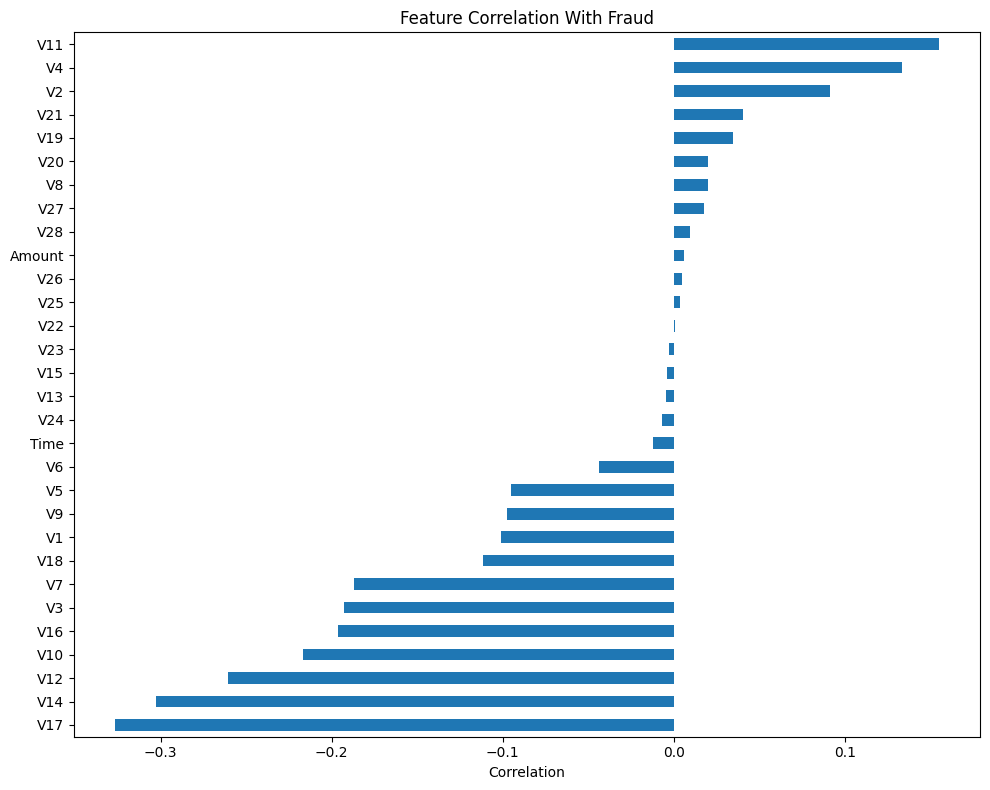

In [19]:
# ============================================================
# CORRELATION WITH TARGET
# ============================================================

plt.figure(figsize=(10, 8))

correlations.drop("Class").plot(
    kind="barh"
)

plt.title("Feature Correlation With Fraud")
plt.xlabel("Correlation")

plt.tight_layout()
plt.show()

In [20]:
# ============================================================
# FEATURES AND TARGET
# ============================================================

X = df.drop("Class", axis=1)
y = df["Class"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (284807, 30)
Target shape: (284807,)


In [21]:
# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training samples: 227845
Testing samples : 56962

Training class distribution:
Class
0    227451
1       394
Name: count, dtype: int64

Testing class distribution:
Class
0    56864
1       98
Name: count, dtype: int64


In [22]:
# ============================================================
# FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Feature scaling completed!")

✅ Feature scaling completed!


In [23]:
# ============================================================
# BASELINE LOGISTIC REGRESSION
# ============================================================

baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

baseline_model.fit(
    X_train_scaled,
    y_train
)

baseline_pred = baseline_model.predict(
    X_test_scaled
)

baseline_prob = baseline_model.predict_proba(
    X_test_scaled
)[:, 1]

print("Baseline model results")
print("=" * 50)

print(
    "Accuracy:",
    accuracy_score(y_test, baseline_pred)
)

print(
    "Precision:",
    precision_score(y_test, baseline_pred)
)

print(
    "Recall:",
    recall_score(y_test, baseline_pred)
)

print(
    "F1:",
    f1_score(y_test, baseline_pred)
)

print(
    "PR-AUC:",
    average_precision_score(y_test, baseline_prob)
)

Baseline model results
Accuracy: 0.9991397773954567
Precision: 0.8266666666666667
Recall: 0.6326530612244898
F1: 0.7167630057803468
PR-AUC: 0.7413820992780461


In [24]:
# ============================================================
# BALANCED LOGISTIC REGRESSION
# ============================================================

lr_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

lr_model.fit(
    X_train_scaled,
    y_train
)

lr_pred = lr_model.predict(
    X_test_scaled
)

lr_prob = lr_model.predict_proba(
    X_test_scaled
)[:, 1]

print("Balanced Logistic Regression")
print("=" * 50)

print("Accuracy :", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall   :", recall_score(y_test, lr_pred))
print("F1       :", f1_score(y_test, lr_pred))
print("PR-AUC   :", average_precision_score(y_test, lr_prob))

Balanced Logistic Regression
Accuracy : 0.9755275446789088
Precision: 0.06097560975609756
Recall   : 0.9183673469387755
F1       : 0.11435832274459974
PR-AUC   : 0.7189705771419241


In [25]:
# ============================================================
# RANDOM FOREST
# ============================================================

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1,
    max_depth=None
)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(
    X_test
)

rf_prob = rf_model.predict_proba(
    X_test
)[:, 1]

print("Random Forest")
print("=" * 50)

print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1       :", f1_score(y_test, rf_pred))
print("PR-AUC   :", average_precision_score(y_test, rf_prob))

Random Forest
Accuracy : 0.9995084442259752
Precision: 0.9605263157894737
Recall   : 0.7448979591836735
F1       : 0.8390804597701149
PR-AUC   : 0.8582554967650086


In [26]:
# ============================================================
# XGBOOST
# ============================================================

negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Scale positive weight:", scale_pos_weight)

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train
)

xgb_pred = xgb_model.predict(
    X_test
)

xgb_prob = xgb_model.predict_proba(
    X_test
)[:, 1]

print("\nXGBoost")
print("=" * 50)

print("Accuracy :", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall   :", recall_score(y_test, xgb_pred))
print("F1       :", f1_score(y_test, xgb_pred))
print("PR-AUC   :", average_precision_score(y_test, xgb_prob))

Scale positive weight: 577.2868020304569

XGBoost
Accuracy : 0.9994733330992591
Precision: 0.8541666666666666
Recall   : 0.8367346938775511
F1       : 0.845360824742268
PR-AUC   : 0.8789385455058787


In [27]:
# ============================================================
# MODEL COMPARISON
# ============================================================

results = pd.DataFrame({
    "Model": [
        "Baseline Logistic Regression",
        "Balanced Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy": [
        accuracy_score(y_test, baseline_pred),
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ],

    "Precision": [
        precision_score(y_test, baseline_pred),
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, xgb_pred)
    ],

    "Recall": [
        recall_score(y_test, baseline_pred),
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred)
    ],

    "F1": [
        f1_score(y_test, baseline_pred),
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred)
    ],

    "PR-AUC": [
        average_precision_score(y_test, baseline_prob),
        average_precision_score(y_test, lr_prob),
        average_precision_score(y_test, rf_prob),
        average_precision_score(y_test, xgb_prob)
    ]
})

results = results.round(4)

display(results)

,Model,Accuracy,Precision,Recall,F1,PR-AUC
0,Baseline Logistic Regression,0.9991,0.8267,0.6327,0.7168,0.7414
1,Balanced Logistic Regression,0.9755,0.0610,0.9184,0.1144,0.7190
2,Random Forest,0.9995,0.9605,0.7449,0.8391,0.8583
3,XGBoost,0.9995,0.8542,0.8367,0.8454,0.8789


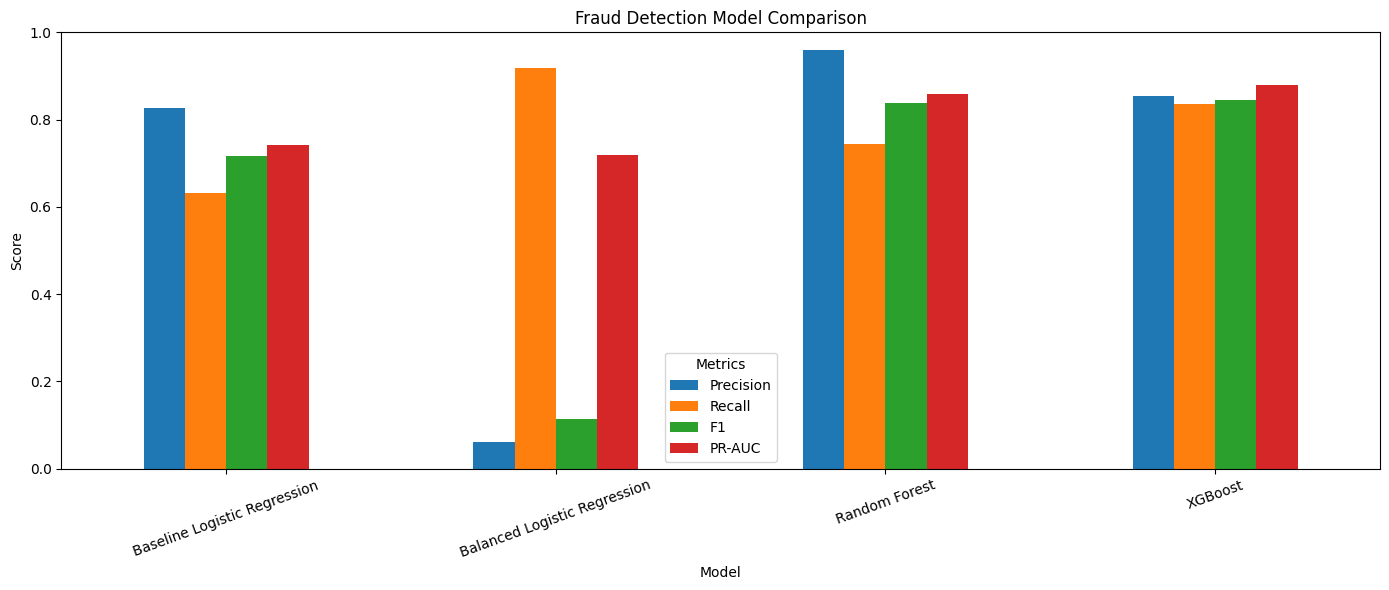

In [28]:
# ============================================================
# MODEL COMPARISON VISUALIZATION
# ============================================================

results_plot = results.set_index("Model")

results_plot[
    ["Precision", "Recall", "F1", "PR-AUC"]
].plot(
    kind="bar",
    figsize=(14, 6)
)

plt.title("Fraud Detection Model Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=20)
plt.ylim(0, 1)

plt.legend(
    title="Metrics"
)

plt.tight_layout()
plt.show()

In [29]:
# ============================================================
# SELECT BEST MODEL
# ============================================================

best_model_name = results.loc[
    results["PR-AUC"].idxmax(),
    "Model"
]

print("🏆 Best model based on PR-AUC:")
print(best_model_name)

🏆 Best model based on PR-AUC:
XGBoost


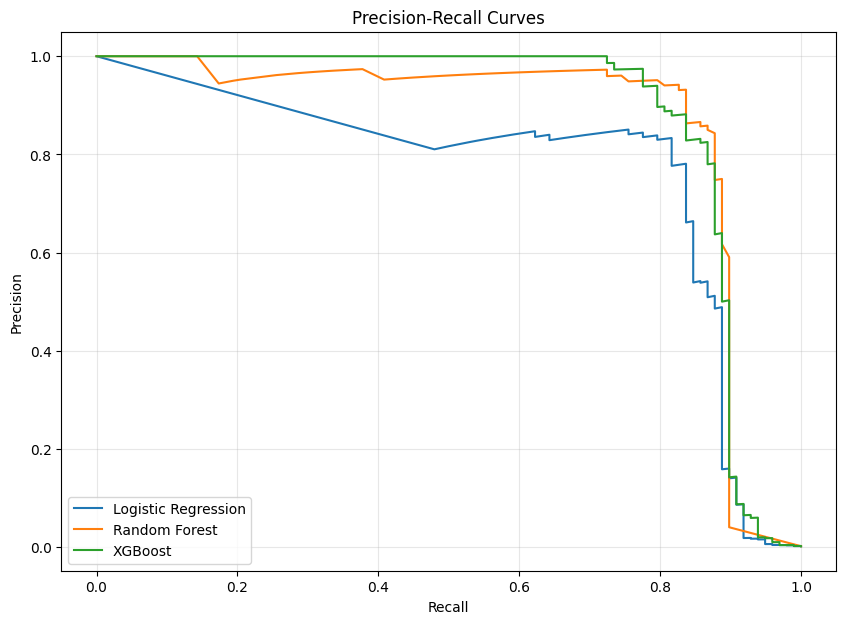

In [30]:
# ============================================================
# PRECISION-RECALL CURVES
# ============================================================

precision_lr, recall_lr, _ = precision_recall_curve(
    y_test,
    lr_prob
)

precision_rf, recall_rf, _ = precision_recall_curve(
    y_test,
    rf_prob
)

precision_xgb, recall_xgb, _ = precision_recall_curve(
    y_test,
    xgb_prob
)

plt.figure(figsize=(10, 7))

plt.plot(
    recall_lr,
    precision_lr,
    label="Logistic Regression"
)

plt.plot(
    recall_rf,
    precision_rf,
    label="Random Forest"
)

plt.plot(
    recall_xgb,
    precision_xgb,
    label="XGBoost"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

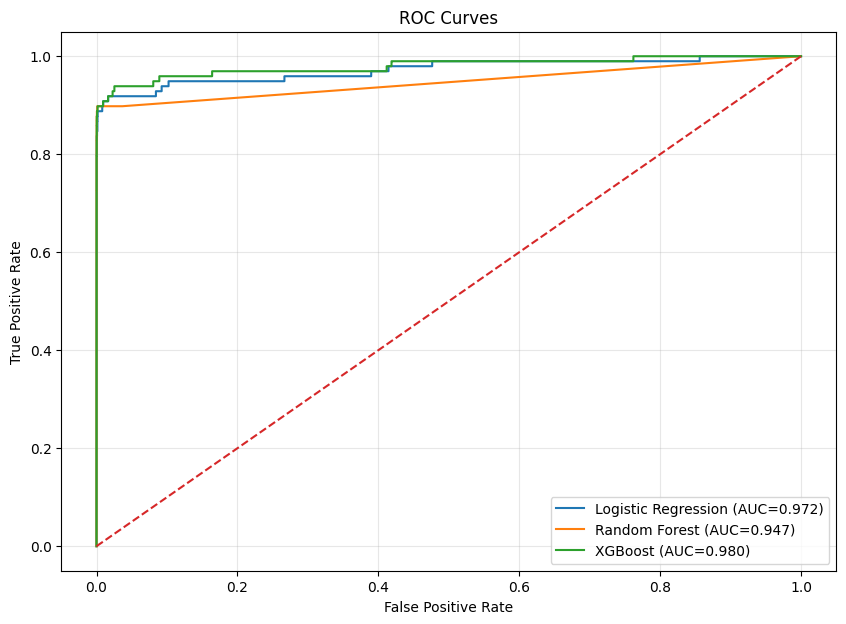

In [31]:
# ============================================================
# ROC CURVES
# ============================================================

fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_prob)

auc_lr = roc_auc_score(y_test, lr_prob)
auc_rf = roc_auc_score(y_test, rf_prob)
auc_xgb = roc_auc_score(y_test, xgb_prob)

plt.figure(figsize=(10, 7))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC={auc_lr:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC={auc_rf:.3f})"
)

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f"XGBoost (AUC={auc_xgb:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curves")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

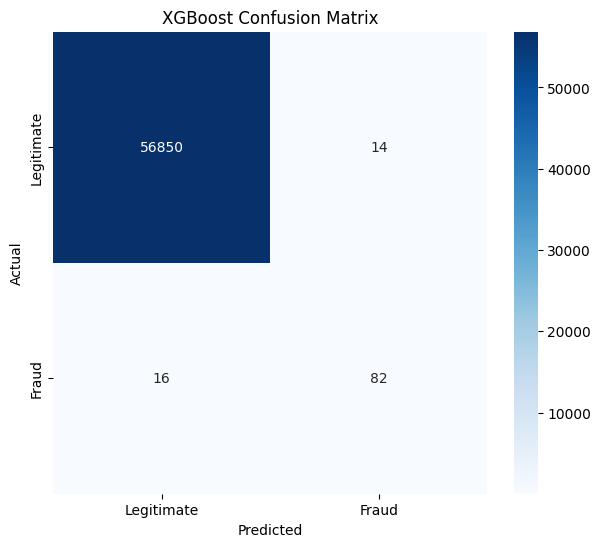

In [32]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    xgb_pred
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("XGBoost Confusion Matrix")

plt.show()

In [33]:
# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print(
    classification_report(
        y_test,
        xgb_pred,
        target_names=[
            "Legitimate",
            "Fraud"
        ],
        digits=4
    )
)

              precision    recall  f1-score   support

  Legitimate     0.9997    0.9998    0.9997     56864
       Fraud     0.8542    0.8367    0.8454        98

    accuracy                         0.9995     56962
   macro avg     0.9269    0.9182    0.9225     56962
weighted avg     0.9995    0.9995    0.9995     56962



In [34]:
# ============================================================
# THRESHOLD OPTIMIZATION
# ============================================================

thresholds = np.arange(
    0.05,
    0.96,
    0.05
)

threshold_results = []

for threshold in thresholds:

    predictions = (
        xgb_prob >= threshold
    ).astype(int)

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

threshold_df = pd.DataFrame(
    threshold_results
)

display(
    threshold_df.round(4)
)

,Threshold,Precision,Recall,F1
0,0.05,0.5210,0.8878,0.6566
1,0.10,0.6772,0.8776,0.7644
2,0.15,0.7350,0.8776,0.8000
3,0.20,0.7818,0.8776,0.8269
4,0.25,0.8173,0.8673,0.8416
5,0.30,0.8173,0.8673,0.8416
6,0.35,0.8317,0.8571,0.8442
7,0.40,0.8317,0.8571,0.8442
8,0.45,0.8367,0.8367,0.8367
9,0.50,0.8542,0.8367,0.8454


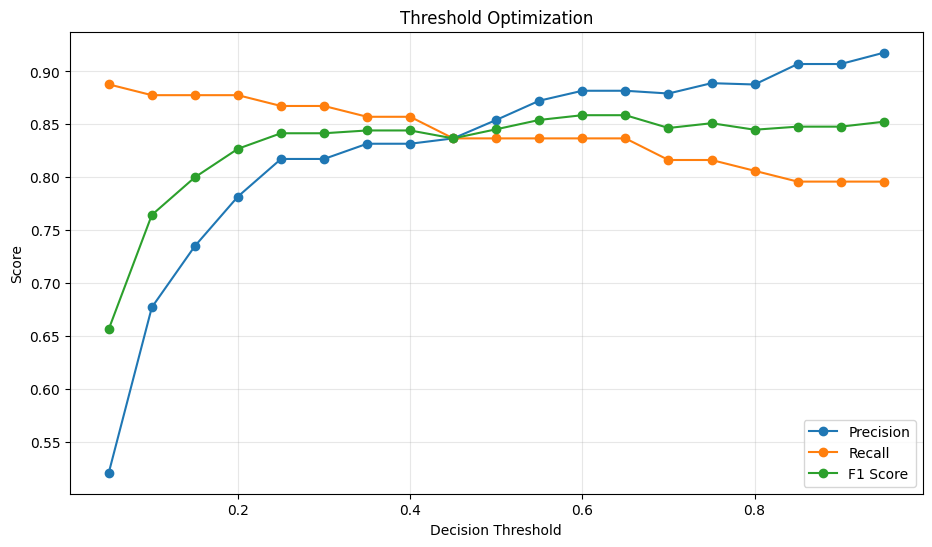

In [35]:
# ============================================================
# THRESHOLD VS PRECISION / RECALL / F1
# ============================================================

plt.figure(figsize=(11, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Score")

plt.title(
    "Threshold Optimization"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [36]:
# ============================================================
# BEST THRESHOLD
# ============================================================

best_threshold_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

BEST_THRESHOLD = float(
    best_threshold_row["Threshold"]
)

print(
    f"🏆 Best threshold: {BEST_THRESHOLD:.2f}"
)

print(
    f"Precision: {best_threshold_row['Precision']:.4f}"
)

print(
    f"Recall: {best_threshold_row['Recall']:.4f}"
)

print(
    f"F1 Score: {best_threshold_row['F1']:.4f}"
)

🏆 Best threshold: 0.60
Precision: 0.8817
Recall: 0.8367
F1 Score: 0.8586


In [37]:
# ============================================================
# FINAL THRESHOLD-BASED PREDICTIONS
# ============================================================

final_pred = (
    xgb_prob >= BEST_THRESHOLD
).astype(int)

print("FINAL MODEL PERFORMANCE")
print("=" * 60)

print(
    "Accuracy :",
    accuracy_score(y_test, final_pred)
)

print(
    "Precision:",
    precision_score(
        y_test,
        final_pred
    )
)

print(
    "Recall   :",
    recall_score(
        y_test,
        final_pred
    )
)

print(
    "F1 Score :",
    f1_score(
        y_test,
        final_pred
    )
)

print(
    "PR-AUC   :",
    average_precision_score(
        y_test,
        xgb_prob
    )
)

FINAL MODEL PERFORMANCE
Accuracy : 0.9995259997893332
Precision: 0.8817204301075269
Recall   : 0.8367346938775511
F1 Score : 0.8586387434554974
PR-AUC   : 0.8789385455058787


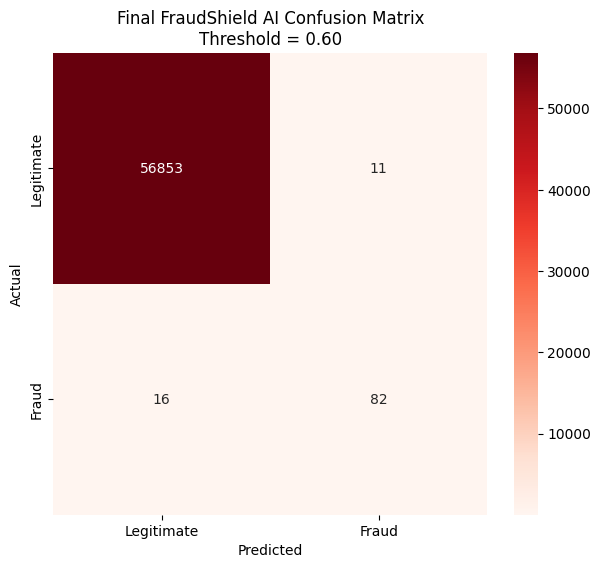

In [38]:
# ============================================================
# FINAL CONFUSION MATRIX
# ============================================================

final_cm = confusion_matrix(
    y_test,
    final_pred
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=[
        "Legitimate",
        "Fraud"
    ],
    yticklabels=[
        "Legitimate",
        "Fraud"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    f"Final FraudShield AI Confusion Matrix\nThreshold = {BEST_THRESHOLD:.2f}"
)

plt.show()

In [39]:
# ============================================================
# FEATURE IMPORTANCE
# ============================================================

importance = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values(
    ascending=False
)

print("Top 15 important features:")
display(
    importance.head(15)
)

Top 15 important features:


,0
V14,0.471668
V10,0.070386
V4,0.063605
V12,0.040101
V20,0.024905
Amount,0.024578
V8,0.022717
V13,0.019673
V26,0.019570
V7,0.017359


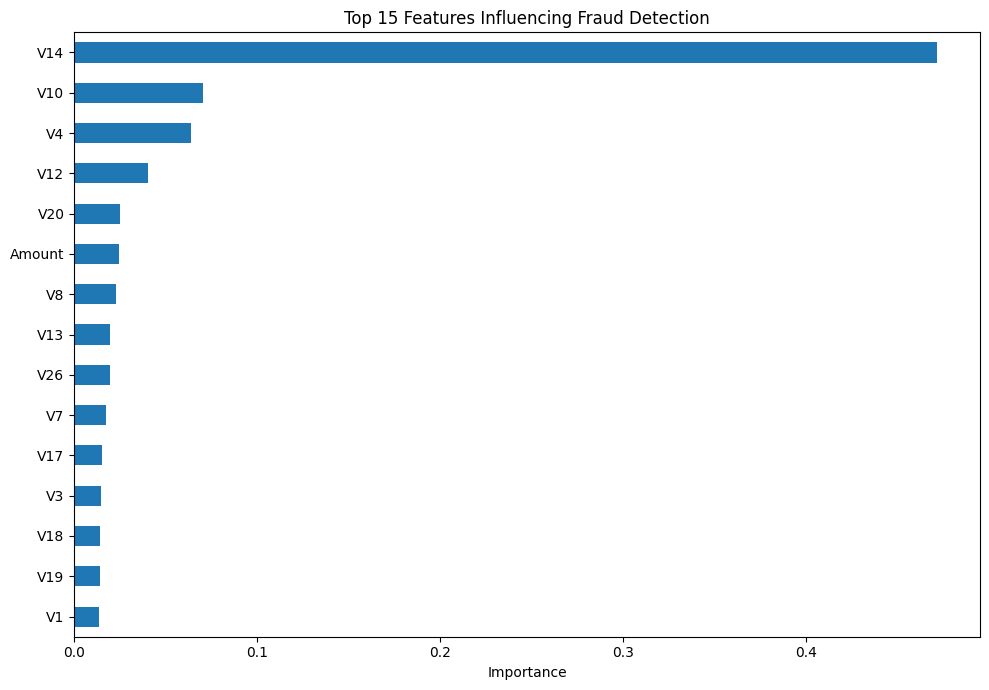

In [40]:
# ============================================================
# FEATURE IMPORTANCE VISUALIZATION
# ============================================================

plt.figure(figsize=(10, 7))

importance.head(15).sort_values().plot(
    kind="barh"
)

plt.title(
    "Top 15 Features Influencing Fraud Detection"
)

plt.xlabel("Importance")

plt.tight_layout()

plt.show()

In [41]:
# ============================================================
# SHAP EXPLAINABILITY
# ============================================================

print("Creating SHAP explainer...")

explainer = shap.TreeExplainer(
    xgb_model
)

# Use a sample to keep SHAP computation fast
X_shap = X_test.sample(
    n=min(2000, len(X_test)),
    random_state=42
)

shap_values = explainer(
    X_shap
)

print("✅ SHAP analysis completed!")

Creating SHAP explainer...
✅ SHAP analysis completed!


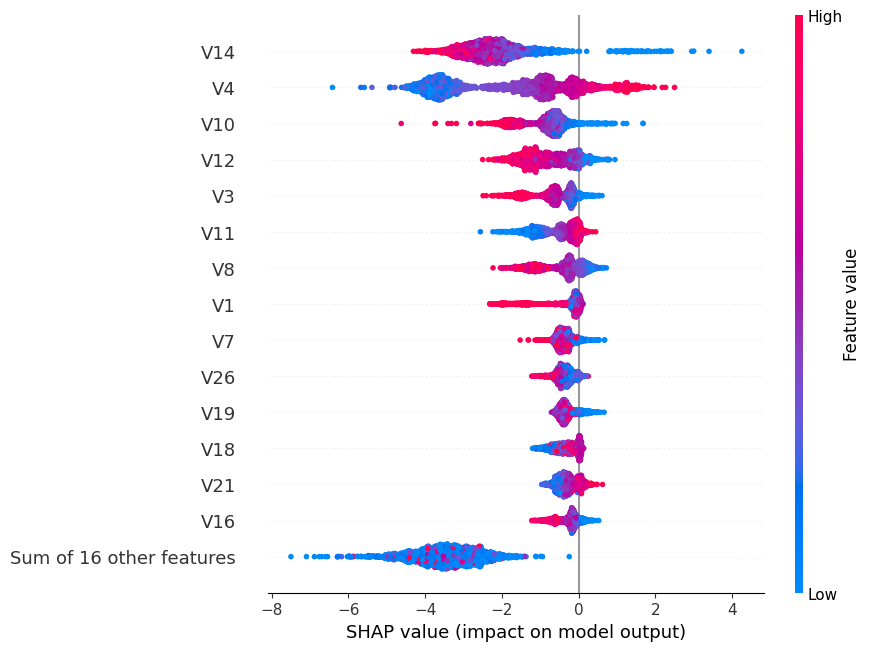

In [42]:
# ============================================================
# SHAP SUMMARY PLOT
# ============================================================

shap.plots.beeswarm(
    shap_values,
    max_display=15,
    show=True
)

In [43]:
# ============================================================
# INDIVIDUAL TRANSACTION EXPLANATION
# ============================================================

sample_index = 0

sample_transaction = X_test.iloc[
    [sample_index]
]

sample_probability = xgb_model.predict_proba(
    sample_transaction
)[0, 1]

sample_prediction = int(
    sample_probability >= BEST_THRESHOLD
)

print(
    f"Fraud probability: {sample_probability:.4f}"
)

print(
    "Prediction:",
    "🚨 FRAUD" if sample_prediction == 1
    else "✅ LEGITIMATE"
)

Fraud probability: 0.0000
Prediction: ✅ LEGITIMATE


In [44]:
# ============================================================
# INDIVIDUAL TRANSACTION EXPLANATION
# ============================================================

sample_index = 0

sample_transaction = X_test.iloc[
    [sample_index]
]

sample_probability = xgb_model.predict_proba(
    sample_transaction
)[0, 1]

sample_prediction = int(
    sample_probability >= BEST_THRESHOLD
)

print(
    f"Fraud probability: {sample_probability:.4f}"
)

print(
    "Prediction:",
    "🚨 FRAUD" if sample_prediction == 1
    else "✅ LEGITIMATE"
)

Fraud probability: 0.0000
Prediction: ✅ LEGITIMATE


In [45]:
# ============================================================
# INTERVENTION / RECOMMENDATION ENGINE
# ============================================================

def generate_recommendation(
    probability
):

    score = probability * 100

    if score < 30:
        return (
            "✅ Transaction appears low risk. "
            "Proceed with normal monitoring."
        )

    elif score < 70:
        return (
            "⚠️ Transaction has moderate risk. "
            "Consider additional verification."
        )

    else:
        return (
            "🚨 Transaction has high fraud risk. "
            "Flag for immediate manual review "
            "and additional customer verification."
        )


recommendation = generate_recommendation(
    sample_probability
)

print("Recommended action:")
print(recommendation)

Recommended action:
✅ Transaction appears low risk. Proceed with normal monitoring.


In [53]:
# ============================================================
# COMPLETE FRAUD ANALYSIS FUNCTION
# ============================================================

def analyze_transaction(index):

    transaction = X_test.iloc[
        [index]
    ]

    probability = xgb_model.predict_proba(
        transaction
    )[0, 1]

    prediction = int(
        probability >= BEST_THRESHOLD
    )

    score, level, emoji = calculate_risk(
        probability
    )

    recommendation = generate_recommendation(
        probability
    )

    result = {
        "Transaction Index": index,
        "Fraud Probability": f"{probability * 100:.2f}%",
        "Risk Score": f"{score:.2f}/100",
        "Risk Level": f"{emoji} {level}",
        "Prediction": (
            "🚨 FRAUD"
            if prediction == 1
            else "✅ LEGITIMATE"
        ),
        "Recommended Action": recommendation
    }

    return result

In [51]:
# ============================================================
# FRAUD RISK SCORING FUNCTION
# ============================================================

def calculate_risk(probability):

    score = probability * 100

    if score < 30:
        level = "LOW"
        emoji = "🟢"

    elif score < 70:
        level = "MEDIUM"
        emoji = "🟡"

    else:
        level = "HIGH"
        emoji = "🔴"

    return score, level, emoji


print("✅ calculate_risk() function is ready!")

✅ calculate_risk() function is ready!


In [52]:
# ============================================================
# RECOMMENDATION ENGINE
# ============================================================

def generate_recommendation(probability):

    score = probability * 100

    if score < 30:
        return (
            "✅ Transaction appears low risk. "
            "Proceed with normal monitoring."
        )

    elif score < 70:
        return (
            "⚠️ Transaction has moderate risk. "
            "Consider additional verification."
        )

    else:
        return (
            "🚨 Transaction has high fraud risk. "
            "Flag for immediate manual review "
            "and additional customer verification."
        )


print("✅ generate_recommendation() function is ready!")

✅ generate_recommendation() function is ready!


In [54]:
# ============================================================
# TEST FRAUDSHIELD AI
# ============================================================

result = analyze_transaction(0)

for key, value in result.items():
    print(f"{key}: {value}")

Transaction Index: 0
Fraud Probability: 0.00%
Risk Score: 0.00/100
Risk Level: 🟢 LOW
Prediction: ✅ LEGITIMATE
Recommended Action: ✅ Transaction appears low risk. Proceed with normal monitoring.


In [55]:
# ============================================================
# FIND ACTUAL FRAUD TRANSACTION
# ============================================================

fraud_indices = np.where(
    y_test.values == 1
)[0]

print(
    "Number of fraud cases in test set:",
    len(fraud_indices)
)

print(
    "Example fraud indices:",
    fraud_indices[:10]
)

Number of fraud cases in test set: 98
Example fraud indices: [ 840 1146 3287 4276 5077 5453 7164 7299 7337 9036]


In [56]:
# ============================================================
# TEST AN ACTUAL FRAUD CASE
# ============================================================

fraud_index = int(
    fraud_indices[0]
)

fraud_result = analyze_transaction(
    fraud_index
)

print("=" * 60)
print("🚨 FRAUD TEST CASE")
print("=" * 60)

for key, value in fraud_result.items():
    print(
        f"{key}: {value}"
    )

🚨 FRAUD TEST CASE
Transaction Index: 840
Fraud Probability: 99.99%
Risk Score: 99.99/100
Risk Level: 🔴 HIGH
Prediction: 🚨 FRAUD
Recommended Action: 🚨 Transaction has high fraud risk. Flag for immediate manual review and additional customer verification.


In [57]:
# ============================================================
# TEST AN ACTUAL LEGITIMATE CASE
# ============================================================

legit_indices = np.where(
    y_test.values == 0
)[0]

legit_index = int(
    legit_indices[0]
)

legit_result = analyze_transaction(
    legit_index
)

print("=" * 60)
print("✅ LEGITIMATE TEST CASE")
print("=" * 60)

for key, value in legit_result.items():
    print(
        f"{key}: {value}"
    )

✅ LEGITIMATE TEST CASE
Transaction Index: 0
Fraud Probability: 0.00%
Risk Score: 0.00/100
Risk Level: 🟢 LOW
Prediction: ✅ LEGITIMATE
Recommended Action: ✅ Transaction appears low risk. Proceed with normal monitoring.


In [58]:
# ============================================================
# 💳 FRAUDSHIELD AI - INTERACTIVE DEMO
# ============================================================

import gradio as gr


def demo_prediction(index):

    index = int(index)

    transaction = X_test.iloc[
        [index]
    ]

    probability = xgb_model.predict_proba(
        transaction
    )[0, 1]

    prediction = int(
        probability >= BEST_THRESHOLD
    )

    score, level, emoji = calculate_risk(
        probability
    )

    recommendation = generate_recommendation(
        probability
    )

    result_text = f"""
# 💳 FraudShield AI

## Analysis Result

**Fraud Probability:** {probability * 100:.2f}%

**Risk Score:** {score:.2f}/100

**Risk Level:** {emoji} {level}

**Prediction:** {
    "🚨 FRAUDULENT TRANSACTION"
    if prediction == 1
    else
    "✅ LEGITIMATE TRANSACTION"
}

---

### Recommended Action

{recommendation}

---

### Model

XGBoost

### Decision Threshold

{BEST_THRESHOLD:.2f}
"""

    return result_text


demo = gr.Interface(
    fn=demo_prediction,

    inputs=gr.Slider(
        minimum=0,
        maximum=len(X_test) - 1,
        step=1,
        value=0,
        label="Select Test Transaction"
    ),

    outputs=gr.Markdown(),

    title="💳 FraudShield AI",

    description=(
        "Intelligent Credit Card Fraud Detection "
        "and Risk Scoring System"
    )
)

demo.launch(
    share=True
)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://56f89f39e1de8b8de3.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [59]:
# ============================================================
# SAVE TRAINED MODEL
# ============================================================

os.makedirs(
    "FraudShield_models",
    exist_ok=True
)

joblib.dump(
    xgb_model,
    "FraudShield_models/fraud_model.pkl"
)

joblib.dump(
    scaler,
    "FraudShield_models/scaler.pkl"
)

joblib.dump(
    BEST_THRESHOLD,
    "FraudShield_models/threshold.pkl"
)

print("✅ Model files saved!")

✅ Model files saved!


In [60]:
# ============================================================
# SAVE MODEL RESULTS
# ============================================================

os.makedirs(
    "FraudShield_results",
    exist_ok=True
)

results.to_csv(
    "FraudShield_results/model_comparison.csv",
    index=False
)

threshold_df.to_csv(
    "FraudShield_results/threshold_analysis.csv",
    index=False
)

print("✅ Results saved!")

✅ Results saved!


In [61]:
# ============================================================
# 🎓 FINAL PROJECT SUMMARY
# ============================================================

final_precision = precision_score(
    y_test,
    final_pred
)

final_recall = recall_score(
    y_test,
    final_pred
)

final_f1 = f1_score(
    y_test,
    final_pred
)

final_pr_auc = average_precision_score(
    y_test,
    xgb_prob
)

print("=" * 70)
print("💳 FRAUDSHIELD AI — FINAL RESULTS")
print("=" * 70)

print(f"Dataset size       : {len(df):,}")
print(f"Fraud cases        : {int(df['Class'].sum()):,}")
print(f"Best model         : XGBoost")
print(f"Decision threshold : {BEST_THRESHOLD:.2f}")
print()
print(f"Precision          : {final_precision:.4f}")
print(f"Recall             : {final_recall:.4f}")
print(f"F1 Score           : {final_f1:.4f}")
print(f"PR-AUC             : {final_pr_auc:.4f}")

print("=" * 70)
print("🚀 FraudShield AI completed successfully!")
print("=" * 70)

💳 FRAUDSHIELD AI — FINAL RESULTS
Dataset size       : 284,807
Fraud cases        : 492
Best model         : XGBoost
Decision threshold : 0.60

Precision          : 0.8817
Recall             : 0.8367
F1 Score           : 0.8586
PR-AUC             : 0.8789
🚀 FraudShield AI completed successfully!
